# E04 — nonlinear elliptic PDE inverse problem


The forward problem is
\[
(-\Delta + q_0 e^m)u=s,
\]
with signed sources and an unknown positive global observation gain. For data adjoint \(\xi\), the adjoint state satisfies the same elliptic operator, and the model-gradient contribution has the form
\[
\nabla_m J = -(q_0e^m u)\odot\lambda + \nabla_m R.
\]
E04 compares \(L^2\), Normalized \(L^2\), vv\(W_2\), and Q-vv\(W_2\). L-BFGS-B iteration progress is printed for every solve, followed by the 12-seed noise Monte Carlo progress.

In [10]:
from IPython.display import display, Image
import os
import sys
import subprocess
from pathlib import Path

# ============================================================
# Locate the qvvw2 repository
# ============================================================

ROOT = Path.cwd().resolve()

for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError(
        "Could not locate the qvvw2 repository root."
    )

os.chdir(ROOT)

# ============================================================
# Make sure the current repository is installed
# ============================================================

def current_qvvw2_path():
    try:
        import qvvw2
        return Path(qvvw2.__file__).resolve()
    except ImportError:
        return None


installed_path = current_qvvw2_path()

need_install = (
    installed_path is None
    or ROOT not in installed_path.parents
)

if need_install:
    print("Preparing local qvvw2 package...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-e",
            str(ROOT),
            "--no-deps",
            "--no-build-isolation",
            "--quiet",
        ],
        check=True,
    )

# Make the current checkout take priority.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import qvvw2

# ============================================================
# Environment used by experiment subprocesses
# ============================================================

existing_pythonpath = os.environ.get(
    "PYTHONPATH",
    ""
)

pythonpath_parts = [
    str(ROOT)
]

if existing_pythonpath:
    pythonpath_parts.append(
        existing_pythonpath
    )

os.environ["PYTHONPATH"] = os.pathsep.join(
    pythonpath_parts
)

print("Repository :", ROOT)
print("Python     :", sys.executable)
print("qvvw2      :", Path(qvvw2.__file__).resolve())


# ============================================================
# Helper for running experiment scripts
# ============================================================

def run_py(relative_path, *args):
    script = ROOT / relative_path

    if not script.exists():
        raise FileNotFoundError(
            f"Experiment script not found: {script}"
        )

    cmd = [
        sys.executable,
        "-u",
        str(script),
        *map(str, args),
    ]

    env = dict(os.environ)

    print(
        "\n" + "=" * 88,
        flush=True,
    )
    print(
        "RUN:",
        " ".join(cmd),
        flush=True,
    )
    print(
        "=" * 88,
        flush=True,
    )

    subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        check=True,
    )


def reset_experiment(exp_id):
    """
    Remove only previously generated results and figures for the
    selected experiment before a fresh rerun.

    Source code, notebooks, inputs, and all other experiments are
    untouched.
    """
    import shutil

    exp = ROOT / "experiments" / exp_id

    for name in ("results", "figures"):
        path = exp / name

        if path.exists():
            shutil.rmtree(path)

    print(
        f"[{exp_id}] previous generated results/figures cleared.",
        flush=True,
    )



Repository : /root/autodl-tmp/qvvw2
Python     : /root/miniconda3/envs/qvvw2/bin/python
qvvw2      : /root/autodl-tmp/qvvw2/qvvw2/__init__.py


In [11]:
reset_experiment("E04")

[E04] previous generated results/figures cleared.


In [12]:
run_py("experiments/E04/code/run_e04.py", "--core")
run_py("experiments/E04/code/run_e04.py", "--mc", 0, 12)
run_py("experiments/E04/code/run_e04.py", "--finalize")
run_py("experiments/E04/code/make_fig07.py")


RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/qvvw2/experiments/E04/code/run_e04.py --core

[E04] Core experiments

[E04] case=clean_g1
[E04 core] inversion 01/16 | L2
[E04 L2] start | maxiter=40 | case=clean_g1
[E04 L2]  1/40 (  2.5%) | obj=6.795e-01 | RE=0.8968 | corr=0.7808
[E04 L2] 10/40 ( 25.0%) | obj=5.285e-04 | RE=0.1579 | corr=0.9877
[E04 L2] 20/40 ( 50.0%) | obj=4.604e-05 | RE=0.0865 | corr=0.9963
[E04 L2] 30/40 ( 75.0%) | obj=1.292e-05 | RE=0.0564 | corr=0.9984
[E04 L2] 40/40 (100.0%) | obj=5.148e-06 | RE=0.0402 | corr=0.9992
[E04 L2] done | nit=40 | RE=0.0402 | corr=0.9992 | time=4.4s
[E04 core] inversion 02/16 | Normalized-L2
[E04 Normalized-L2] start | maxiter=40 | case=clean_g1
[E04 Normalized-L2]  1/40 (  2.5%) | obj=6.761e-01 | RE=0.8966 | corr=0.7790
[E04 Normalized-L2] 10/40 ( 25.0%) | obj=4.388e-04 | RE=0.1581 | corr=0.9875
[E04 Normalized-L2] 20/40 ( 50.0%) | obj=4.291e-05 | RE=0.0831 | corr=0.9966
[E04 Normalized-L2] 30/40 ( 75.0%) | obj=9.492e-0


 Fig07_elliptic_reconstructions.png


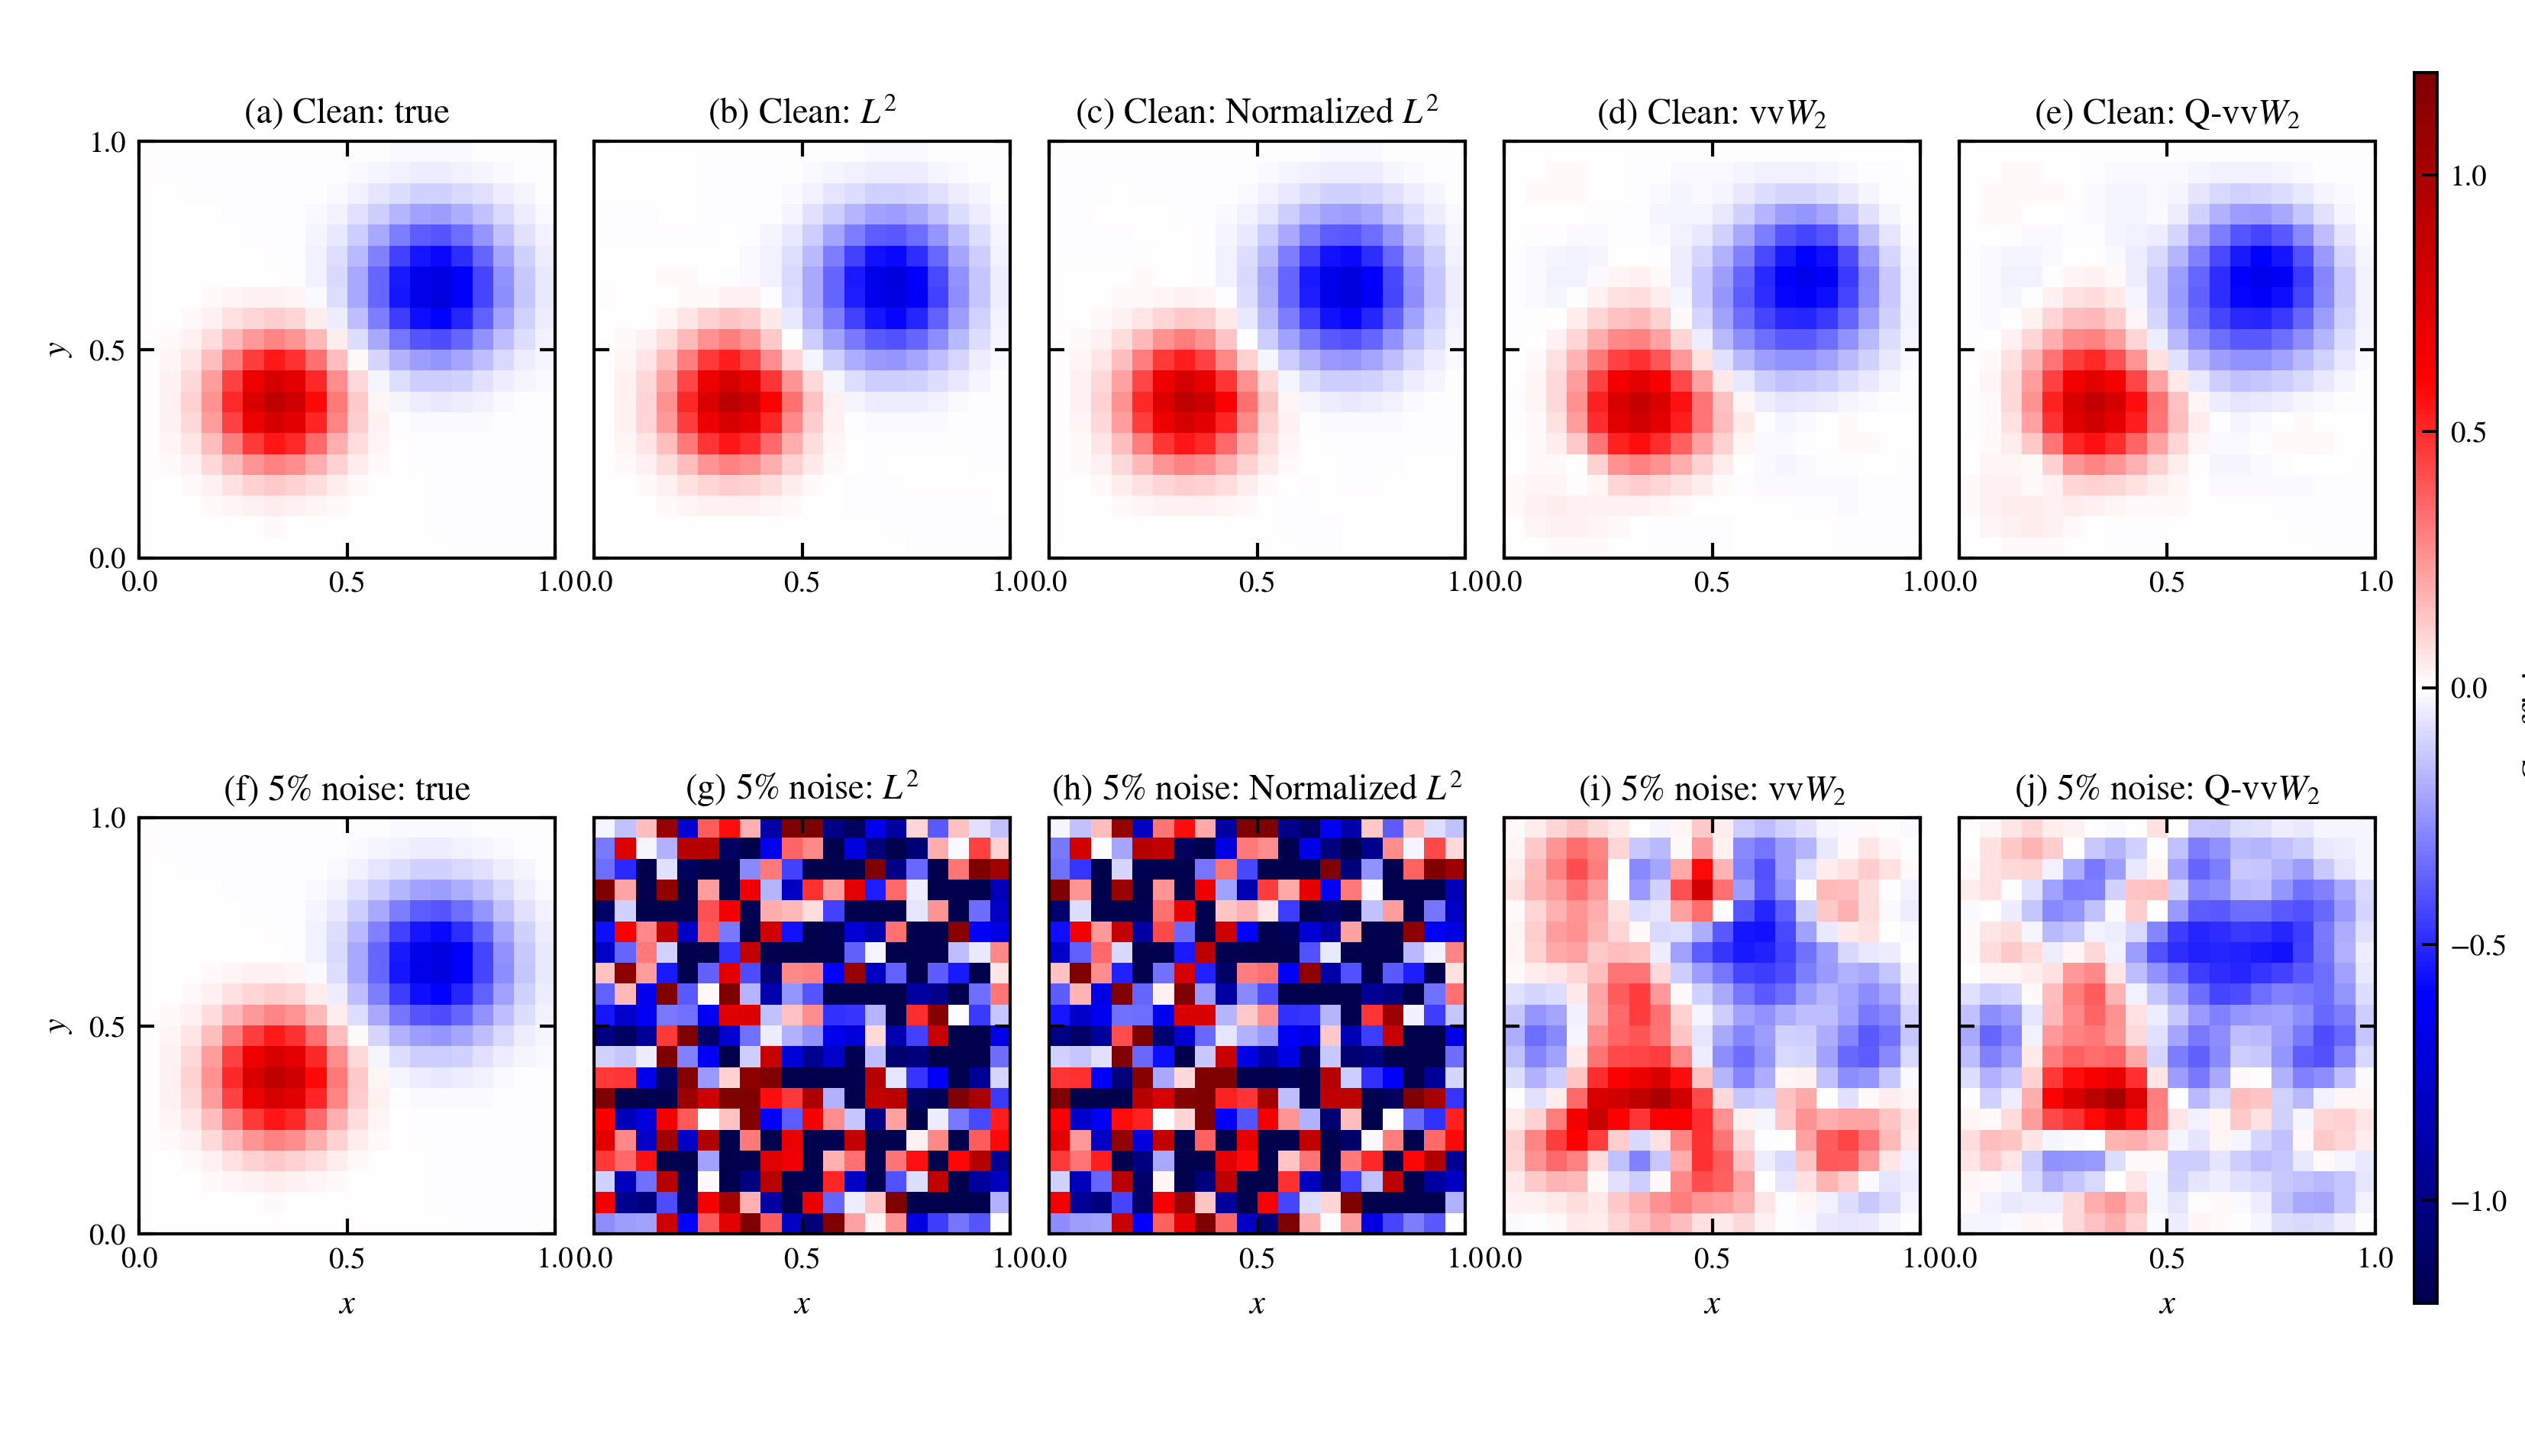


 Fig08_elliptic_robustness.png


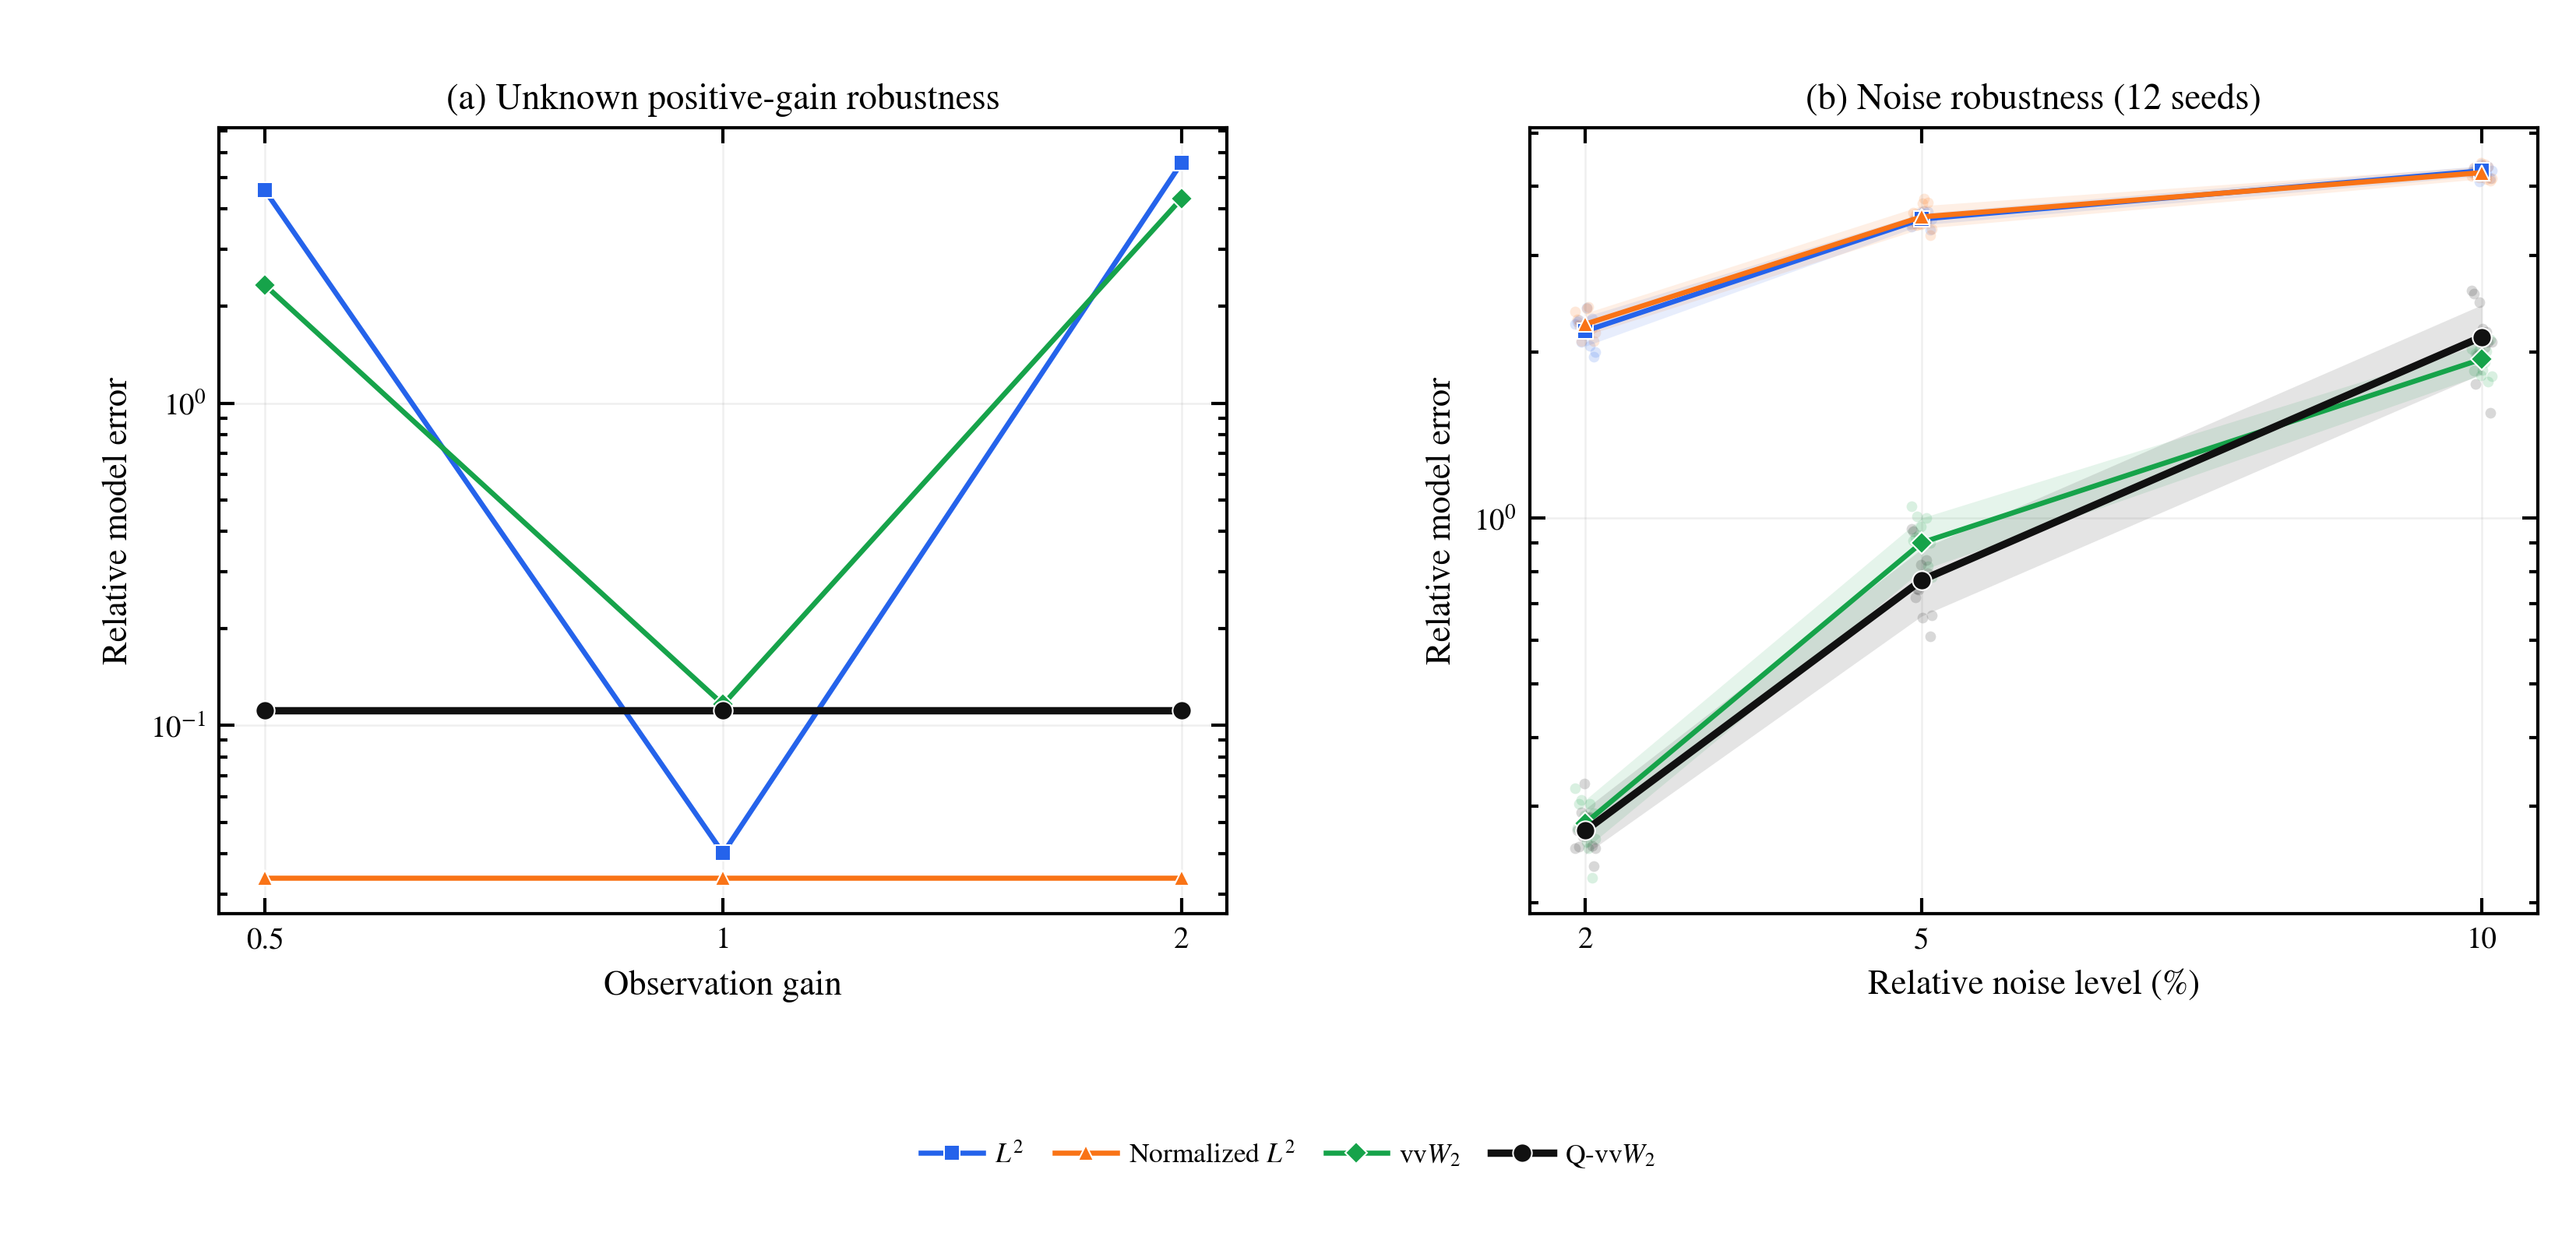

In [14]:
def show_png(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))

for name in ["Fig07_elliptic_reconstructions.png", "Fig08_elliptic_robustness.png"]:
    print("\n", name)
    show_png(ROOT / "experiments/E04/figures" / name)